Struktur Data (Data Structure)

In [21]:
# IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# LOAD DATA
df = pd.read_csv('E:\Python - Project\phone-addiction-detection\Data\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

# DEFINE NUMERIC COLUMNS
num_cols = df.select_dtypes(include=np.number).columns

In [22]:
print("=== HEAD DATA ===")
print(df.head())

=== HEAD DATA ===
  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1       

Analisis Data Kosong (Missing Values)

In [23]:
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print(missing_df)


=== MISSING VALUES ===
                         Missing Count  Percentage (%)
addiction_level                    819           10.92
transaction_id                       0            0.00
user_id                              0            0.00
age                                  0            0.00
gender                               0            0.00
daily_screen_time_hours              0            0.00
social_media_hours                   0            0.00
gaming_hours                         0            0.00
work_study_hours                     0            0.00
sleep_hours                          0            0.00
notifications_per_day                0            0.00
app_opens_per_day                    0            0.00
weekend_screen_time                  0            0.00
stress_level                         0            0.00
academic_work_impact                 0            0.00
addicted_label                       0            0.00


Statistik Deskriptif & Distribusi Data

In [24]:
# Cek skewness (kemiringan data) untuk menguji normalitas
print(df.describe())

numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['addicted_label'])
print("Skewness Features Numerik:\n", numeric_df.skew())

               age  daily_screen_time_hours  social_media_hours  gaming_hours  \
count  7500.000000              7500.000000         7500.000000   7500.000000   
mean     26.568800                 7.499912            3.273484      2.014183   
std       5.197108                 2.609188            1.585342      1.146039   
min      18.000000                 3.000000            0.500000      0.000000   
25%      22.000000                 5.220000            1.910000      1.020000   
50%      27.000000                 7.525000            3.270000      2.040000   
75%      31.000000                 9.810000            4.630000      2.990000   
max      35.000000                12.000000            6.000000      4.000000   

       work_study_hours  sleep_hours  notifications_per_day  \
count       7500.000000  7500.000000            7500.000000   
mean           3.242420     6.737561             134.257333   
std            1.600765     1.283605              66.586883   
min            0.5

DISTRIBUSI DATA (HISTOGRAM)

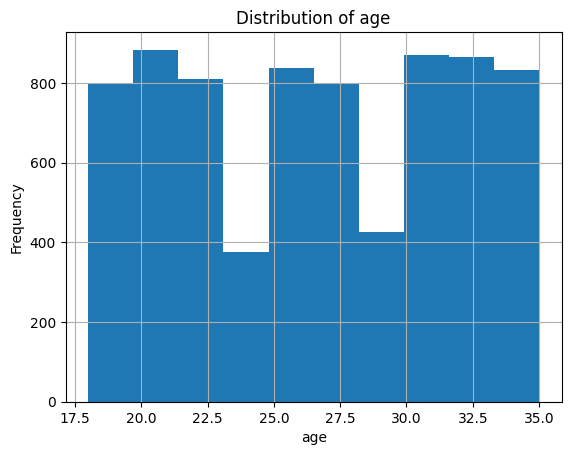

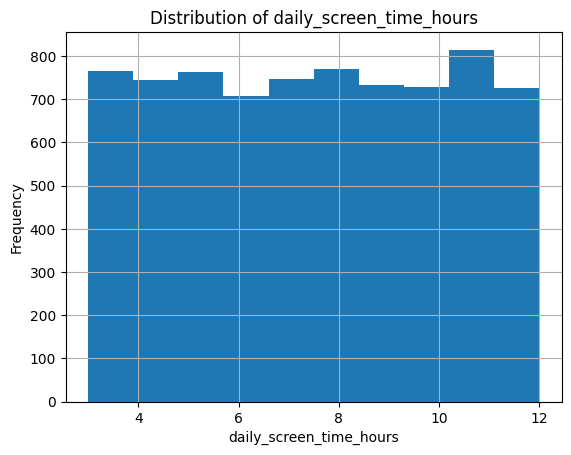

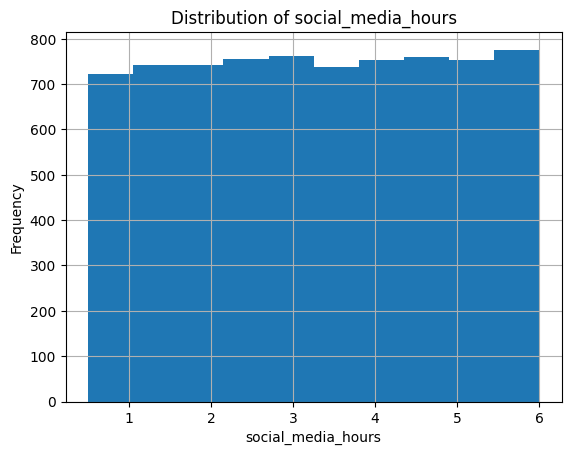

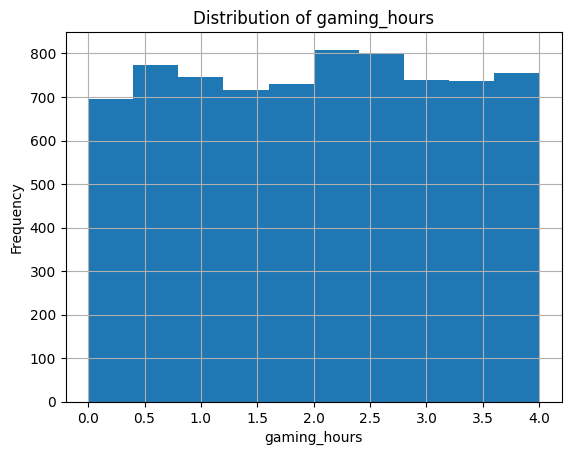

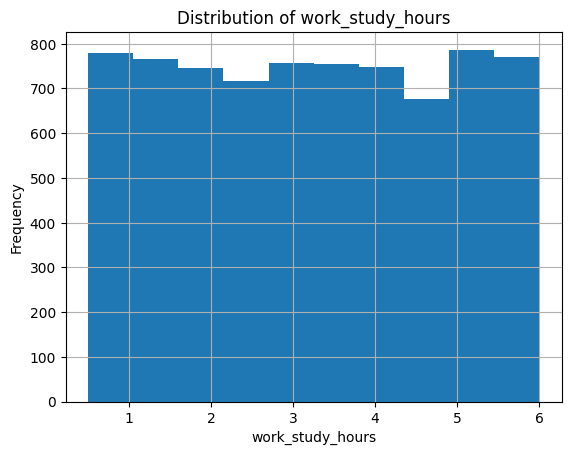

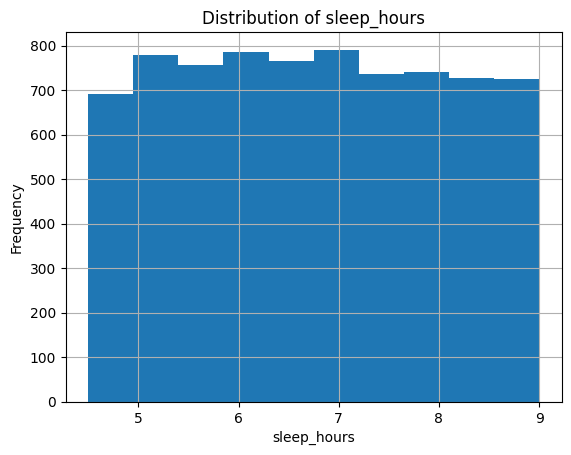

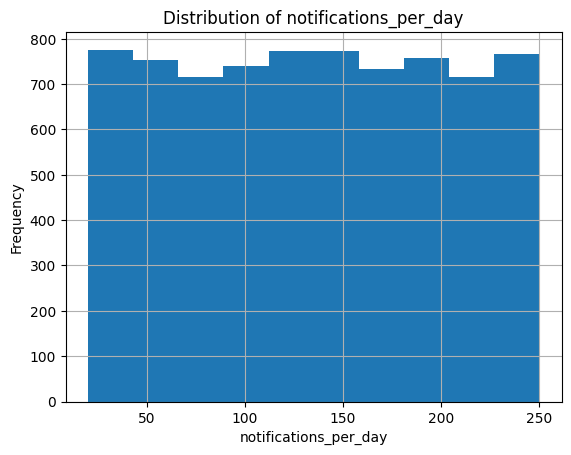

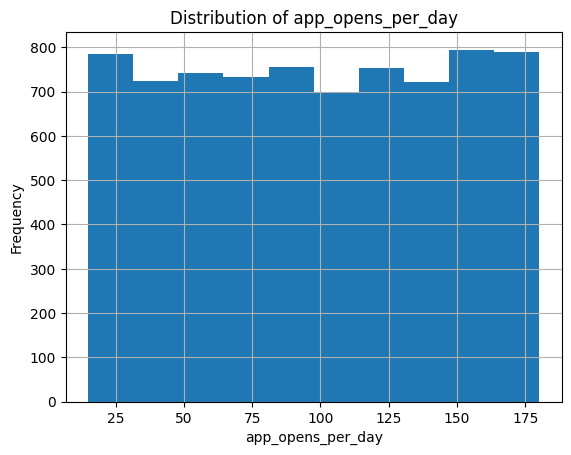

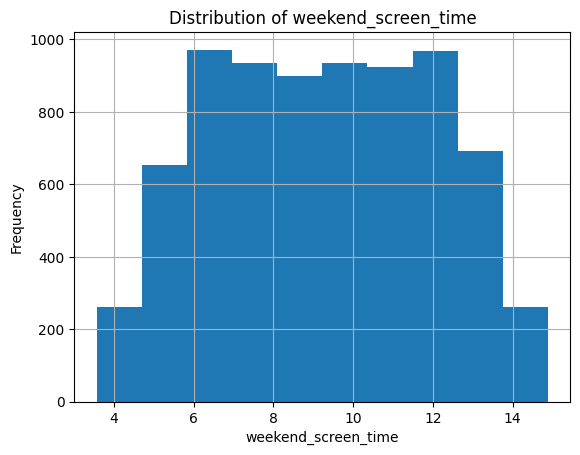

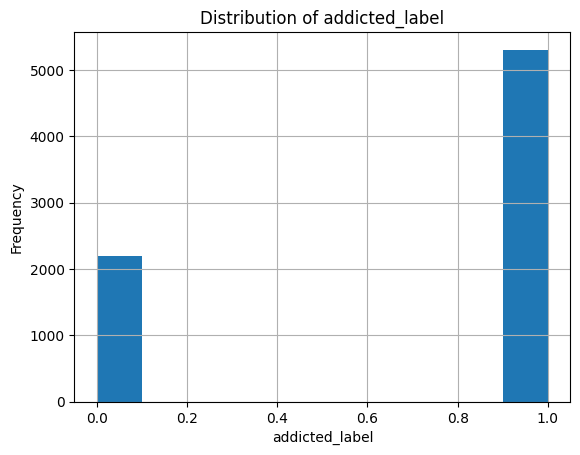

In [25]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    df[col].hist()
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


OUTLIER DETECTION (BOXPLOT)

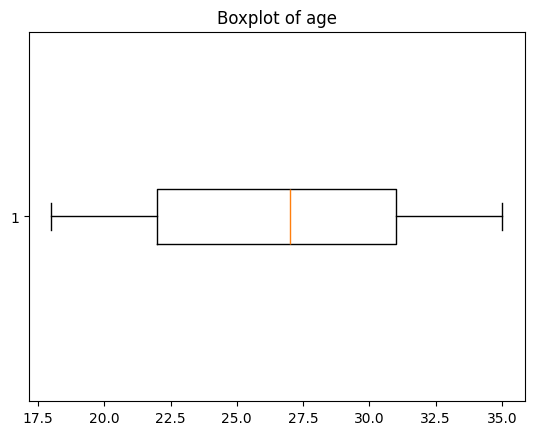

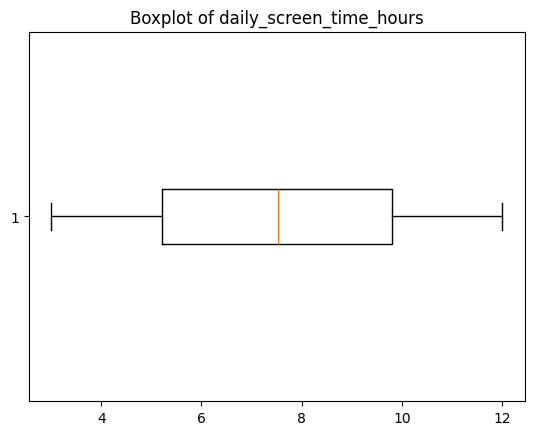

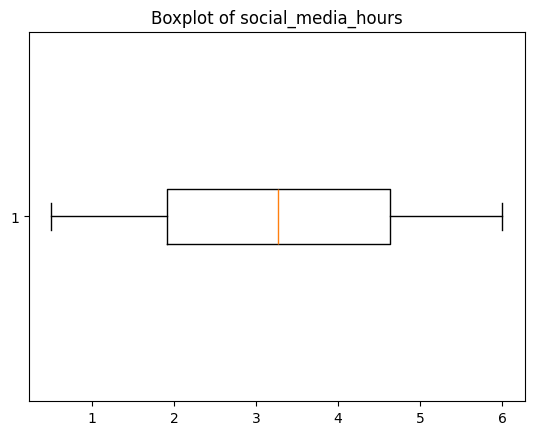

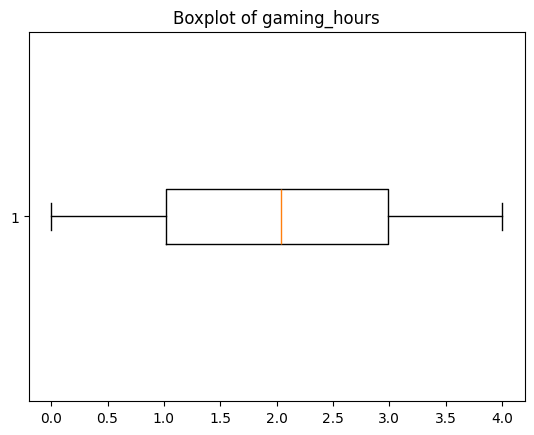

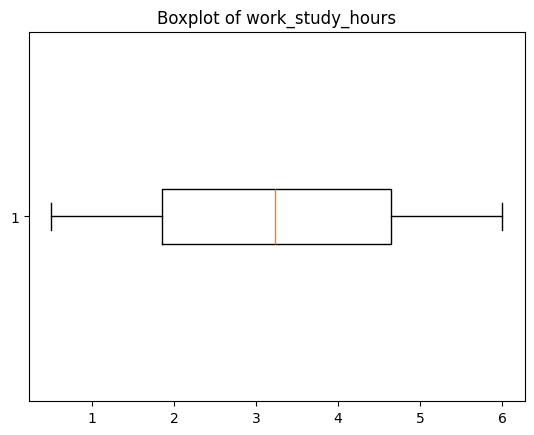

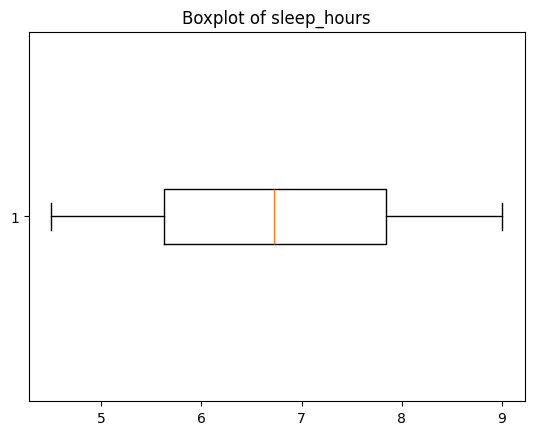

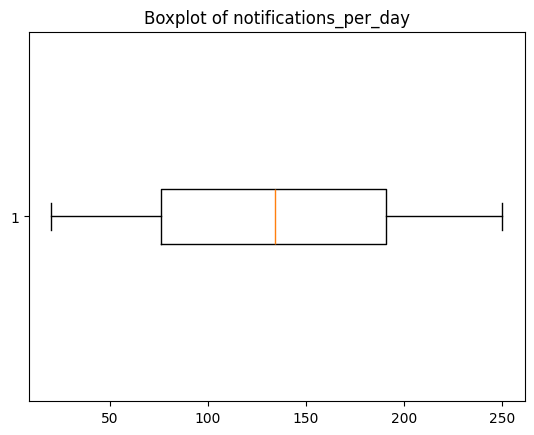

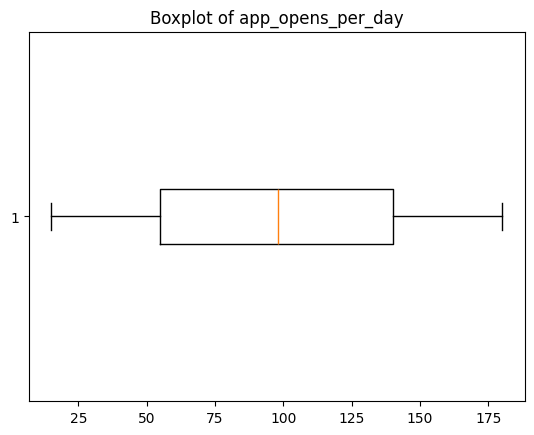

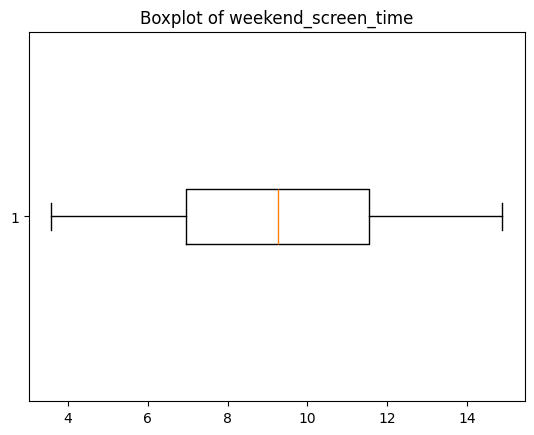

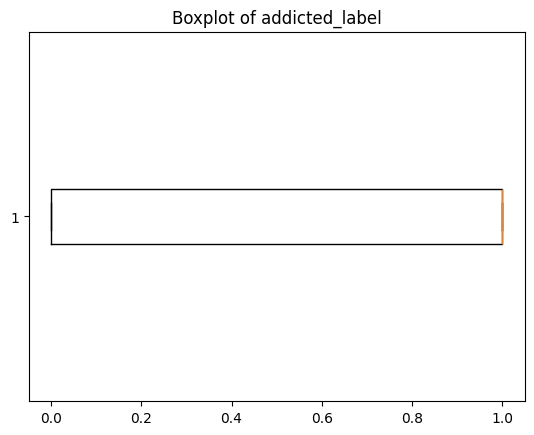

In [26]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

KORELASI

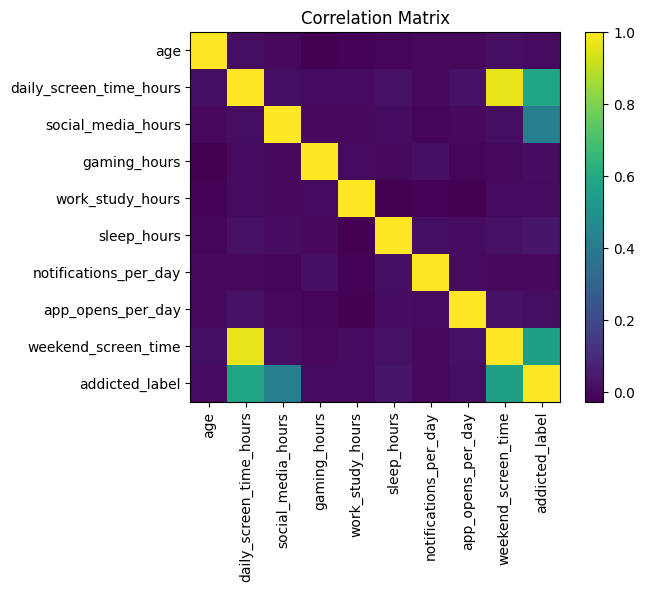

In [27]:
corr = df[num_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

DATA KATEGORIKAL

C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_1052\230653771.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


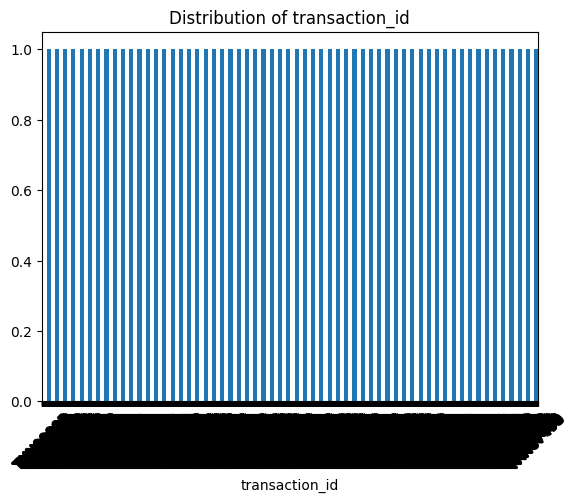

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


CEK DUPLIKASI

In [ ]:
duplicates = df.duplicated().sum()
print("\n=== DUPLICATE DATA ===")
print(duplicates)

 CEK IMBALANCE (JIKA ADA TARGET)


In [ ]:
# Ganti 'target_column' sesuai dataset kamu
target_column = None  # contoh: 'Addiction_Level'

if target_column and target_column in df.columns:
    print("\n=== TARGET DISTRIBUTION ===")
    print(df[target_column].value_counts())

    plt.figure()
    df[target_column].value_counts().plot(kind='bar')
    plt.title('Target Distribution')
    plt.show()